In [2]:
"""
Usage:
1. Put this script and your coordinate CSV in the same folder.
2. Rename the coordinate CSV to example_data.csv.
3. The CSV must contain columns: Frame, p11, p12, p13, p14, p15, p16, p23, p24, p25, p26.
4. Each point cell should look like: "(x, y, z)".
5. Run: python calculate_pose_angles.py
6. The output file computed_angles.csv will be created in the same folder.
"""

import ast
import csv
import math
from pathlib import Path


# SCRIPT_DIR = Path(__file__).resolve().parent
INPUT_CSV = "data.csv"
OUTPUT_CSV = "computed_angles.csv"


ANGLE_DEFINITIONS = [
    ("angle_11_13_15_at_13", 11, 13, 15),
    ("angle_12_14_16_at_14", 12, 14, 16),
    ("angle_11_13_23_at_13", 11, 13, 23),
    ("angle_12_14_24_at_14", 12, 14, 24),
    ("angle_11_23_25_at_23", 11, 23, 25),
    ("angle_12_24_26_at_24", 12, 24, 26),
]


def parse_point(text):
    return tuple(float(value) for value in ast.literal_eval(text))


def subtract(a, b):
    return (a[0] - b[0], a[1] - b[1], a[2] - b[2])


def dot(a, b):
    return a[0] * b[0] + a[1] * b[1] + a[2] * b[2]


def norm(a):
    return math.sqrt(dot(a, a))


def angle_degrees(point_a, vertex_b, point_c):
    """Return angle ABC in degrees. The middle point B is the vertex."""
    vector_ba = subtract(point_a, vertex_b)
    vector_bc = subtract(point_c, vertex_b)
    denominator = norm(vector_ba) * norm(vector_bc)

    if denominator == 0:
        return ""

    cosine = dot(vector_ba, vector_bc) / denominator
    cosine = max(-1.0, min(1.0, cosine))
    return math.degrees(math.acos(cosine))


def main():
    # if not INPUT_CSV.exists():
    #     raise FileNotFoundError(f"Cannot find {INPUT_CSV}. Put this script next to example_data.csv.")

    with open(INPUT_CSV, "r", newline="", encoding="utf-8") as input_file:
        reader = csv.DictReader(input_file)
        output_fields = ["Frame"] + [name for name, _, _, _ in ANGLE_DEFINITIONS]

        with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as output_file:
            writer = csv.DictWriter(output_file, fieldnames=output_fields)
            writer.writeheader()

            for row in reader:
                points = {
                    landmark_id: parse_point(row[f"p{landmark_id}"])
                    for _, a, b, c in ANGLE_DEFINITIONS
                    for landmark_id in (a, b, c)
                }

                output_row = {"Frame": row["Frame"]}
                for name, a, b, c in ANGLE_DEFINITIONS:
                    value = angle_degrees(points[a], points[b], points[c])
                    output_row[name] = "" if value == "" else round(value, 6)

                writer.writerow(output_row)

    print(f"Saved {OUTPUT_CSV}")


if __name__ == "__main__":
    main()

Saved computed_angles.csv


In [3]:
# Read everything in the data file into lines
# lines is a list, each element is one line in the data file
def readLDFdata(filepath):
    file_path = filepath
    file = open("" + file_path + ".txt", "r")
    lines = file.readlines()


    # Finds where the raw data starts
    # Skips the two blank lines at very beginning
    i = 0
    while lines[i] != "4) Trace Data\n":
        i += 1
    i += 2


    # Read All Raw LDF Data
    raw_data_ldf = []
    for j in range(i, len(lines)):
        line = lines[j]
        ldf_val = float(line.split("\t")[4])
        raw_data_ldf.append(ldf_val)

    # See if the last datapoint is correct
    return raw_data_ldf


In [4]:
a = readLDFdata("marco grea eagle spreading wings 05.07.26")

In [5]:
a

[78.2,
 70.3,
 49.2,
 45.8,
 51.8,
 33.3,
 58.7,
 70.0,
 52.5,
 52.4,
 42.3,
 43.7,
 39.2,
 31.9,
 69.6,
 78.0,
 65.1,
 49.1,
 44.4,
 45.5,
 45.8,
 46.6,
 84.3,
 80.6,
 66.9,
 63.1,
 55.4,
 52.8,
 48.0,
 68.5,
 115.2,
 119.4,
 90.8,
 78.6,
 76.4,
 85.9,
 72.1,
 89.1,
 124.9,
 157.7,
 149.7,
 128.1,
 129.1,
 137.1,
 122.5,
 105.2,
 118.9,
 171.6,
 162.7,
 163.3,
 142.8,
 106.9,
 94.9,
 110.4,
 124.5,
 149.2,
 138.0,
 137.6,
 123.5,
 120.2,
 115.0,
 96.2,
 117.7,
 155.6,
 149.3,
 141.6,
 140.2,
 126.4,
 123.4,
 130.7,
 179.2,
 173.1,
 160.8,
 154.5,
 128.0,
 123.9,
 104.9,
 131.9,
 162.2,
 145.2,
 140.4,
 141.4,
 114.3,
 106.7,
 113.5,
 147.6,
 171.8,
 159.6,
 146.1,
 130.9,
 130.7,
 128.7,
 121.3,
 149.4,
 171.8,
 153.5,
 137.1,
 149.4,
 151.1,
 140.3,
 111.5,
 106.2,
 152.7,
 144.1,
 139.6,
 131.0,
 113.8,
 106.9,
 87.2,
 76.4,
 118.0,
 143.8,
 136.1,
 129.5,
 104.4,
 93.0,
 88.1,
 99.7,
 148.6,
 120.8,
 101.3,
 118.9,
 99.1,
 67.0,
 75.8,
 119.1,
 124.8,
 120.0,
 133.4,
 110.4,
 99.6,

In [6]:
import pandas as pd
df =pd.read_csv("computed_angles.csv")

In [7]:
df

,Frame,angle_11_13_15_at_13,angle_12_14_16_at_14,angle_11_13_23_at_13,angle_12_14_24_at_14,angle_11_23_25_at_23,angle_12_24_26_at_24
0,0,129.590014,116.175985,124.912264,138.465878,148.037279,139.156722
1,1,126.379033,118.021340,122.368150,138.722129,147.620648,139.046698
2,2,121.374170,124.149590,120.281517,137.625307,145.911208,139.112150
3,3,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050
4,4,121.606588,127.000455,118.519490,138.820362,143.210587,137.050462
...,...,...,...,...,...,...,...
16838,16838,110.222926,130.073280,111.410524,68.643144,158.130050,162.703204
16839,16839,113.012458,129.271175,106.328327,64.365965,157.092217,157.516273
16840,16840,111.357265,125.262786,106.586613,68.353013,158.354846,158.803948
16841,16841,107.910413,126.388713,114.519760,67.938677,156.171776,158.976021


In [8]:
every_third_row = df.iloc[::3]
every_third_row.reset_index(drop=True)
every_third_row

,Frame,angle_11_13_15_at_13,angle_12_14_16_at_14,angle_11_13_23_at_13,angle_12_14_24_at_14,angle_11_23_25_at_23,angle_12_24_26_at_24
0,0,129.590014,116.175985,124.912264,138.465878,148.037279,139.156722
3,3,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050
6,6,118.394850,120.576245,114.231931,138.109628,136.118053,142.061438
9,9,110.740615,116.207194,110.173619,137.729528,136.320260,127.414221
12,12,119.378066,128.308051,109.435626,137.684705,131.934455,129.129593
...,...,...,...,...,...,...,...
16830,16830,106.776337,128.964524,119.191217,63.353146,159.059405,161.310681
16833,16833,101.395593,130.427763,125.541303,60.752745,158.453255,162.549781
16836,16836,104.116091,129.284041,117.807976,61.799694,154.592711,153.436793
16839,16839,113.012458,129.271175,106.328327,64.365965,157.092217,157.516273


In [9]:
a.extend([None] * (5615 - len(a)))

In [10]:
every_third_row['LDF_bloodflow'] = a

C:\Users\willi\AppData\Local\Temp\ipykernel_19880\2203942439.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  every_third_row['LDF_bloodflow'] = a


In [11]:
real_df = every_third_row

In [13]:
real_df

,Frame,angle_11_13_15_at_13,angle_12_14_16_at_14,angle_11_13_23_at_13,angle_12_14_24_at_14,angle_11_23_25_at_23,angle_12_24_26_at_24,LDF_bloodflow
0,0,129.590014,116.175985,124.912264,138.465878,148.037279,139.156722,78.2
3,3,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050,70.3
6,6,118.394850,120.576245,114.231931,138.109628,136.118053,142.061438,49.2
9,9,110.740615,116.207194,110.173619,137.729528,136.320260,127.414221,45.8
12,12,119.378066,128.308051,109.435626,137.684705,131.934455,129.129593,51.8
...,...,...,...,...,...,...,...,...
16830,16830,106.776337,128.964524,119.191217,63.353146,159.059405,161.310681,NaN
16833,16833,101.395593,130.427763,125.541303,60.752745,158.453255,162.549781,NaN
16836,16836,104.116091,129.284041,117.807976,61.799694,154.592711,153.436793,NaN
16839,16839,113.012458,129.271175,106.328327,64.365965,157.092217,157.516273,NaN


In [15]:
real_df['LDF_bloodflow'] = real_df['LDF_bloodflow'].shift(1)


C:\Users\willi\AppData\Local\Temp\ipykernel_19880\139685191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df['LDF_bloodflow'] = real_df['LDF_bloodflow'].shift(1)


In [17]:
real_df.dropna()

,Frame,angle_11_13_15_at_13,angle_12_14_16_at_14,angle_11_13_23_at_13,angle_12_14_24_at_14,angle_11_23_25_at_23,angle_12_24_26_at_24,LDF_bloodflow
3,3,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050,78.2
6,6,118.394850,120.576245,114.231931,138.109628,136.118053,142.061438,70.3
9,9,110.740615,116.207194,110.173619,137.729528,136.320260,127.414221,49.2
12,12,119.378066,128.308051,109.435626,137.684705,131.934455,129.129593,45.8
15,15,118.756626,120.751706,107.211508,138.927584,136.734354,129.293823,51.8
...,...,...,...,...,...,...,...,...
16191,16191,126.558970,126.229852,117.884974,128.156434,159.287323,150.249733,242.0
16194,16194,109.627106,123.724462,138.668702,124.997420,161.543813,152.687602,264.2
16197,16197,128.533910,121.779417,110.023072,124.789669,161.587409,155.591636,248.1
16200,16200,121.335940,133.200483,125.047038,125.011081,161.080992,152.221299,242.1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = real_df.drop(columns=['LDF_bloodflow'])
y = real_df['LDF_bloodflow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 2. LINEAR REGRESSION MODEL
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=5, 
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

In [12]:
real_df

,Frame,angle_11_13_15_at_13,angle_12_14_16_at_14,angle_11_13_23_at_13,angle_12_14_24_at_14,angle_11_23_25_at_23,angle_12_24_26_at_24,LDF_bloodflow
0,0,129.590014,116.175985,124.912264,138.465878,148.037279,139.156722,78.2
3,3,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050,70.3
6,6,118.394850,120.576245,114.231931,138.109628,136.118053,142.061438,49.2
9,9,110.740615,116.207194,110.173619,137.729528,136.320260,127.414221,45.8
12,12,119.378066,128.308051,109.435626,137.684705,131.934455,129.129593,51.8
...,...,...,...,...,...,...,...,...
16830,16830,106.776337,128.964524,119.191217,63.353146,159.059405,161.310681,NaN
16833,16833,101.395593,130.427763,125.541303,60.752745,158.453255,162.549781,NaN
16836,16836,104.116091,129.284041,117.807976,61.799694,154.592711,153.436793,NaN
16839,16839,113.012458,129.271175,106.328327,64.365965,157.092217,157.516273,NaN


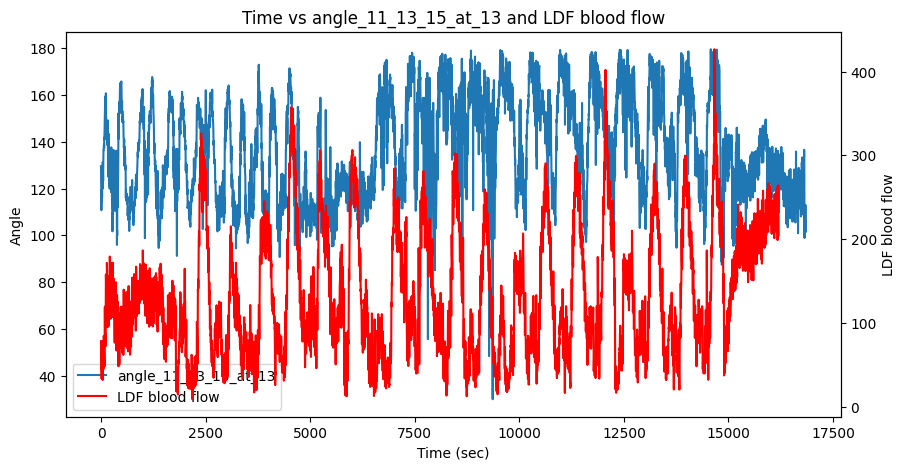

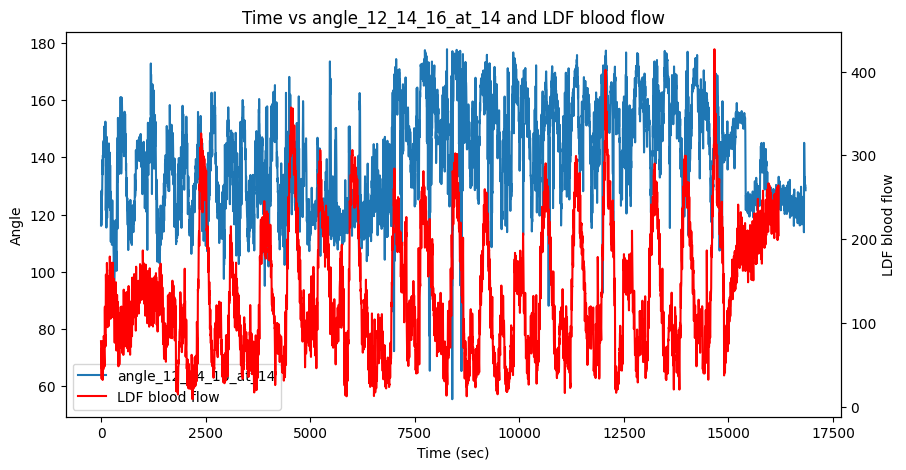

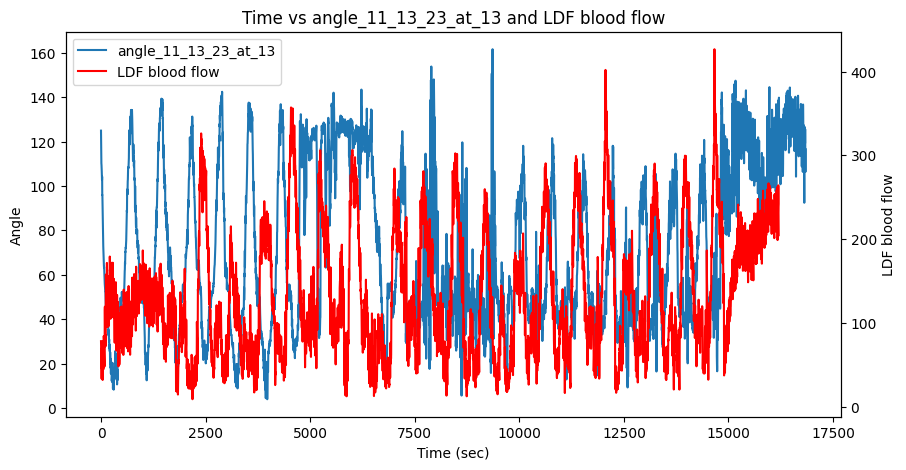

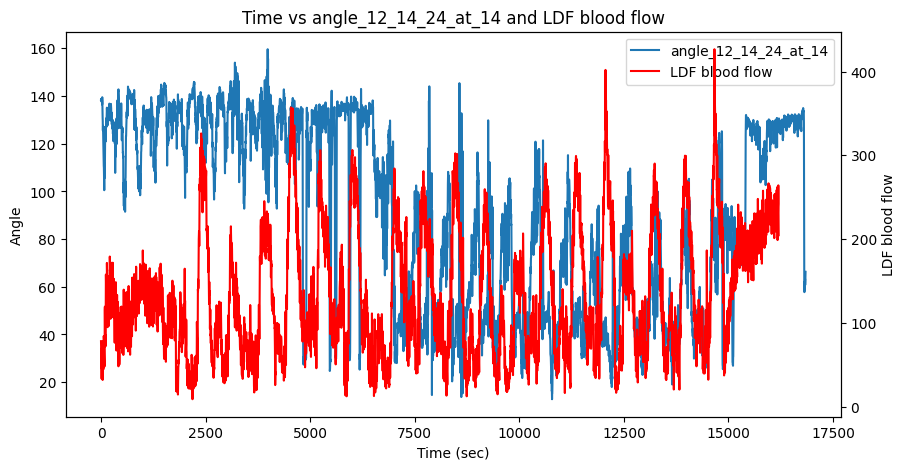

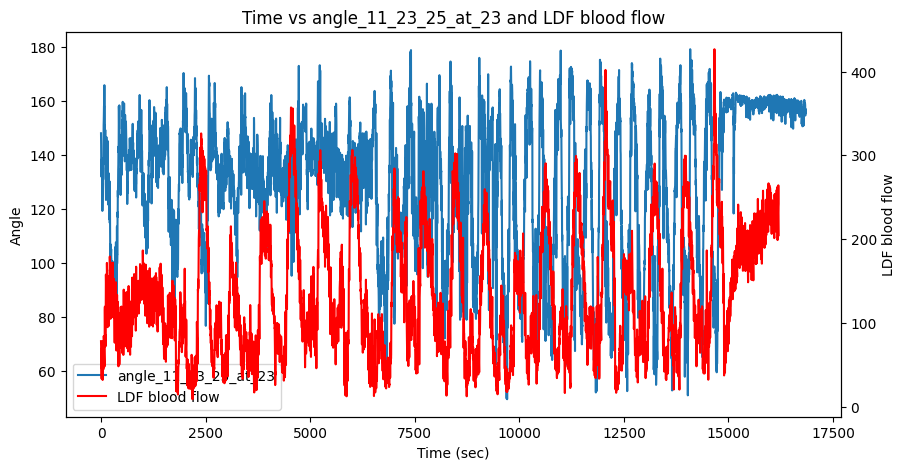

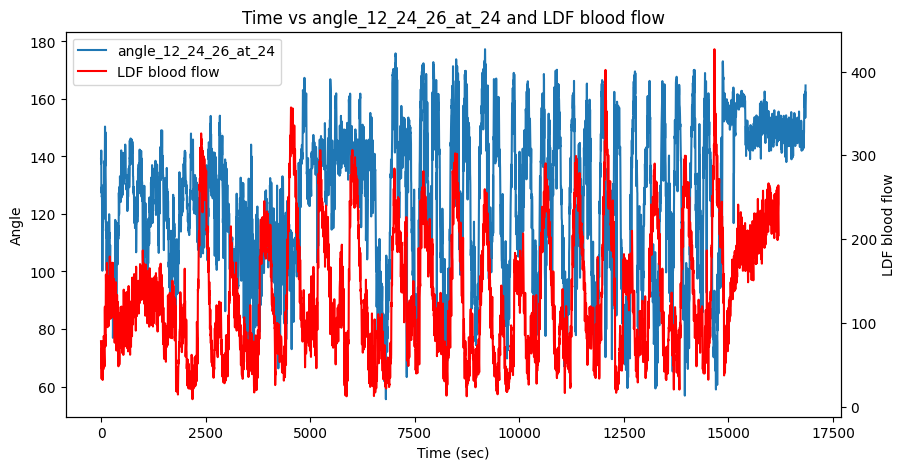

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
df = real_df#pd.read_csv("compileddata.csv")

time_col = "Frame"
ldf_col = "LDF_bloodflow"

#gets every column that starts with "angle_"
angle_cols = [col for col in df.columns if col.startswith("angle_")]

for angle_col in angle_cols:
    plt.figure(figsize=(10,5))

    #left y-axis: angle
    plt.plot(df[time_col], df[angle_col], label=angle_col)
    plt.xlabel("Time (sec)")
    plt.ylabel("Angle")

    #right y-axis: LDF blood flow
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax2.plot(df[time_col],df[ldf_col], label="LDF blood flow", color="red")
    ax2.set_ylabel("LDF blood flow")

    plt.title(f"Time vs {angle_col} and LDF blood flow")

    #combine legends from both y-axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    plt.show()